<a href="https://colab.research.google.com/github/shannonmalach/Geospatial_Python_Projects/blob/main/Commercial_Development_Service_Access.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spatial Analysis of Commercial Development and Public Service Accessibility in Fairfax County

#### Shannon Malach

#### Displaying shopping centers in Fairfax County


In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon, LineString

In [ ]:
# retrieving census tract data for Virginia state
# data source: https://www2.census.gov/geo/tiger/TIGER2022/TRACT/
va_tract = gpd.read_file("https://www2.census.gov/geo/tiger/TIGER2022/TRACT/tl_2022_51_tract.zip")

In [ ]:
# viewing tract 460702's data
tract = va_tract[va_tract['TRACTCE'] == '460702']
tract

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
1649,51,059,460702,51059460702,4607.02,Census Tract 4607.02,G5020,S,2829180,0,+38.8926878,-077.2632296,"POLYGON ((-77.27566 38.89341, -77.27505 38.893..."


In [ ]:
# retrieving shopping center data
# data source: https://services1.arcgis.com/ioennV6PpG5Xodq0/ArcGIS/rest/services/OpenData_S1/FeatureServer/3/query?outFields=*&where=1%3D1&f=geojson
shopping_ctrs = gpd.read_file("https://services1.arcgis.com/ioennV6PpG5Xodq0/ArcGIS/rest/services/OpenData_S1/FeatureServer/3/query?outFields=*&where=1%3D1&f=geojson")

In [ ]:
# checking the CRSs of both datasets
print(va_tract.crs)
print(shopping_ctrs.crs)

EPSG:4269
EPSG:4326


In [ ]:
# converting shopping center data CRS to the census tract's CRS
shopping_ctrs = shopping_ctrs.to_crs(va_tract.crs)

<class 'shapely.geometry.multipoint.MultiPoint'>


/tmp/ipykernel_221/2307893697.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  shopping_ctrs_geom = shopping_ctrs.geometry.unary_union


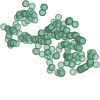

In [ ]:
# using unary_union to merge polygons into a multipolygon
shopping_ctrs_geom = shopping_ctrs.geometry.unary_union

# displaying type of geometry and visualization of the data
print(type(shopping_ctrs_geom))
shopping_ctrs_geom

In [ ]:
# rechecking the CRSs of both datasets
print(va_tract.crs)
print(shopping_ctrs.crs)

EPSG:4269
EPSG:4269


In [ ]:
# viewing tract 460702's data
tract = va_tract[va_tract['TRACTCE'] == '460702']
tract

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
1649,51,059,460702,51059460702,4607.02,Census Tract 4607.02,G5020,S,2829180,0,+38.8926878,-077.2632296,"POLYGON ((-77.27566 38.89341, -77.27505 38.893..."


#### Finding shopping centers within the tract and ones labeled 'plaza'

(3, 9)


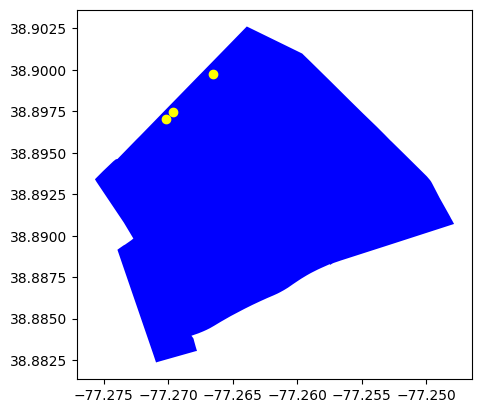

In [ ]:
# subsetting the shopping center data to find points that lie within the tract
ctrs_in_tract = shopping_ctrs[shopping_ctrs.geometry.within(tract.geometry[1649])]

# printing the tract with the shopping centers that lie within it
plot1=tract.plot(color='blue')
ctrs_in_tract.plot(ax=plot1, color='yellow')

# printing the number of shopping centers within the tract
print(ctrs_in_tract.shape)

In [ ]:
# calculating and printing the amount of shopping centers in this tract that have 'PLAZA' in their description
count = ctrs_in_tract['DESCRIPTION'].str.contains('PLAZA', case=False, na=False).sum()
print(count)

1


#### Displaying unique zoning district types in Fairfax County

In [ ]:
# retrieving zoning district data
# data source: https://services1.arcgis.com/ioennV6PpG5Xodq0/arcgis/rest/services/Zoning/FeatureServer/0/query?outFields=*&where=1%3D1&f=geojson
zoning_districts = gpd.read_file("https://services1.arcgis.com/ioennV6PpG5Xodq0/arcgis/rest/services/Zoning/FeatureServer/0/query?outFields=*&where=1%3D1&f=geojson")

In [ ]:
# identifying and printing the unique zoning types
unique_zones = zoning_districts['ZONETYPE'].unique()
print(unique_zones)

['RESIDENTIAL' 'COMMERCIAL' 'PLANNED UNITS' 'INDUSTRIAL']


In [ ]:
# checking if dataset is in CRS or PCS
zoning_districts.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [ ]:
# converting to a PCS - State Plane Coordinate System NAD 83 Virginia North (EPSG:2283)
zoning_districts = zoning_districts.to_crs(epsg=2283)

ZONETYPE
COMMERCIAL       1.096353e+08
INDUSTRIAL       1.112156e+08
PLANNED UNITS    5.003932e+08
RESIDENTIAL      1.164155e+09
Name: area_km2, dtype: float64


<Axes: >

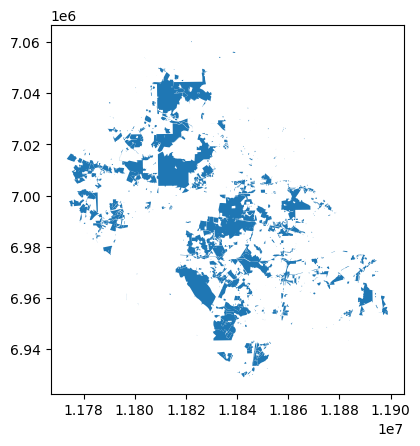

In [ ]:
# calculating the areas for each zoning polygon
zoning_districts['area_km2'] = zoning_districts.geometry.area
print(zoning_districts['area_km2'])

# dissolving by zoning boundaries based on their zoning district type column
zoning_districts = zoning_districts.dissolve(by='ZONETYPE', aggfunc={'area_km2': 'sum'})
zoning_districts

# displaying visualization with dissolved boundaries
zoning_districts.plot()

#### Identifying buildings located in a 100m buffer zone around commercial zones

In [ ]:
# checking the string data to make sure it matches
print(zoning_districts.index)

# selecting COMMERCIAL zones only
commercial_zones = zoning_districts.loc['COMMERCIAL']

# creating a 100m buffer zone around COMMERCIAL zoning areas
commercial_buffers = commercial_zones.geometry.buffer(.1)
commercial_buffers



Index(['COMMERCIAL', 'INDUSTRIAL', 'PLANNED UNITS', 'RESIDENTIAL'], dtype='object', name='ZONETYPE')


In [ ]:
# retrieving building data
# data source: https://services1.arcgis.com/ioennV6PpG5Xodq0/arcgis/rest/services/Buildings/FeatureServer/0/query?outFields=*&where=1%3D1&f=geojson
buildings = gpd.read_file("https://services1.arcgis.com/ioennV6PpG5Xodq0/arcgis/rest/services/Buildings/FeatureServer/0/query?outFields=*&where=1%3D1&f=geojson")

In [ ]:
# converting buildings buffer to EPSG 2283
buildings_reprojected = buildings.to_crs(epsg=2283)

# converting commercial_buffers into a GeoDataFrame
buffer_gdf = gpd.GeoDataFrame(geometry=[commercial_buffers], crs=zoning_districts.crs)

# joining buildings that intersect the buffer zones
buildings_intersecting_buffer = gpd.sjoin(
    buildings_reprojected,
    buffer_gdf,
    how='inner',
    predicate='intersects'
)

# joining the buildings that lie within the buffer zones
buildings_within_buffer = gpd.sjoin(
    buildings_reprojected,
    buffer_gdf,
    how='inner',
    predicate='within'
)

# printing
print("Intersecting count:", len(buildings_intersecting_buffer))
print("Within count:", len(buildings_within_buffer))
print("When using intersects, it returns more results than using within. This is because intersects returns all datapoints that")
print("make contact with the buffer zones while within requires datapoints to be completely within the zone.")

Intersecting count: 19
Within count: 18
When using intersects, it returns more results than using within. This is because intersects returns all datapoints that
make contact with the buffer zones while within requires datapoints to be completely within the zone.


#### Identifying buildings that are not within 5km of a library

In [ ]:
# retrieving libraries dataset
# data source: https://services1.arcgis.com/ioennV6PpG5Xodq0/arcgis/rest/services/Libraries/FeatureServer/3/query?outFields=*&where=1%3D1&f=geojson
libraries = gpd.read_file("https://services1.arcgis.com/ioennV6PpG5Xodq0/arcgis/rest/services/Libraries/FeatureServer/3/query?outFields=*&where=1%3D1&f=geojson")

In [ ]:
# converting to a PCS - WGS 84 Pseudo-Mercator (EPSG:3857)
libraries = libraries.to_crs(epsg = 3857)

# creating a 5km buffer around each library while updating the geometry of the dataset
libraries = libraries.geometry.buffer(5000)
libraries

,0
0,"POLYGON ((-8595260.486 4705307.141, -8595260.4..."
1,"POLYGON ((-8601532.038 4716425.693, -8601532.0..."
2,"POLYGON ((-8601315.02 4701119.222, -8601315.02..."
3,"POLYGON ((-8582160.684 4713313.409, -8582160.6..."
4,"POLYGON ((-8610685.542 4698664.584, -8610685.5..."
5,"POLYGON ((-8569941.764 4685239.008, -8569941.7..."
6,"POLYGON ((-8607047.572 4705120.6, -8607047.572..."
7,"POLYGON ((-8596915.442 4691503.434, -8596915.4..."
8,"POLYGON ((-8577524.73 4700635.764, -8577524.73..."
9,"POLYGON ((-8574830.055 4690848.31, -8574830.05..."


In [ ]:
# converting librart to a GeoDataFrame
libraries_gdf = gpd.GeoDataFrame(geometry=libraries, crs="epsg:3857")

# reprojecting the libraries_gdf to the same CRS as buffer_gdf (EPSG:2283)
libraries_gdf_reprojected = libraries_gdf.to_crs(buffer_gdf.crs)

# performing an overlay using the difference operation for buildings not falling inside library buffer zones
buildings_outside_buffer = gpd.overlay(libraries_gdf_reprojected, buffer_gdf, how='difference')
buildings_outside_buffer

,geometry
0,"MULTIPOLYGON (((11849400.684 7006912.336, 1184..."
1,"MULTIPOLYGON (((11832985.085 7034991.26, 11832..."
2,"POLYGON ((11834062.802 6996032.832, 11834017.9..."
3,"POLYGON ((11882583.866 7027783.625, 11882541.4..."
4,"POLYGON ((11810171.061 6989467.605, 11810125.0..."
5,"MULTIPOLYGON (((11914982.212 6956748.458, 1191..."
6,"POLYGON ((11819267.646 7006031.97, 11819222.14..."
7,"POLYGON ((11845656.689 6971678.046, 11845612.3..."
8,"MULTIPOLYGON (((11894936.966 6995689.473, 1189..."
9,"MULTIPOLYGON (((11902229.804 6970852.539, 1190..."


In [ ]:
print("I used the difference overlay option because it gives the areas in the first layer (buildings) that do not fall in the second")
print("layer (buffer zones)")

I used the difference overlay option because it gives the areas in the first layer (buildings) that do not fall in the second
layer (buffer zones)
Yes, you could've used a spatial join in this case to identify the buildings inside the buffer zones to then exclude them.
